# Weighted Regression
This script will build a relationship between the MODIS NIR data and the Landsat/Sentinel SLA data

Perform the Regression in two different ways, for both drop all data points (MODIS and LS) with weights lower than 0.2
Then perform one regular OLS (unweighted linear regression) and perform one WLS (weighted linear regression) that additionally weights the SLA from the Landsat/ Sentinel Data. The results of both regression then get compared. 

In [1]:
# Setup and Imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
import plotly.graph_objects as go
import glob
import os
from IPython.display import display
import matplotlib.pyplot as plt

# Define directories
ls_output_dir = '../data/LS_Data/weighted_smoothed'
modis_output_dir = '../data/MODIS_data/weighted_data'

# Find all the Landsat files
ls_files = glob.glob(f"{ls_output_dir}/LS_*_complete.csv")

master_results = [] # stores summary stats
trained_models = {} # stores full WLS regression objects

## 1. Perform the Regression
To establish the relationship between MODIS NIR and Landsat/Sentinel Snowline Altitude (SLA), we perform a regression analysis on observations of the same day.
Observations from either sensor with a quality weight below 0.2 are excluded to improve data quality. Both an Ordinary Least Squares (OLS) model and a Weighted Least Squares (WLS) model are performed. The WLS model utilizes the Landsat/Sentinel quality weights to prioritize high-confidence SLA observations.

In [5]:
# Define the target glaciers
study_glaciers = ['Ulluchiran', 'Lekziri', 'Caneri', 'Bezengi', 'Dyh-Cu', 'Agashtan', 'Karaugom']

#regression loop
clean_datasets = {}

for ls_path in ls_files:
    
    file_name = os.path.basename(ls_path)
    name = file_name.split('_')[1] 

    if name not in study_glaciers:
        continue
    
    modis_path = f"{modis_output_dir}/MODIS_{name}_complete.csv"
    
    if not os.path.exists(modis_path):
        continue

    # Read both the Landsat/Sentinel files and MODIS files
    ls_df = pd.read_csv(ls_path)
    modis_df = pd.read_csv(modis_path)

    # Convert both to datetime and define both as 'date'
    ls_df['date'] = pd.to_datetime(ls_df['time_date-string']).dt.date
    modis_df['date'] = pd.to_datetime(modis_df['date']).dt.date

    # Merge the two datasets, use 'date' as key
    df_merged = pd.merge(ls_df, modis_df, on='date', how='inner')

    # Drop the bad data, everything with a weight of 0.2 and below
    clean_df = df_merged[
        (df_merged['MODIS_weight_final'] >= 0.2) & 
        (df_merged['LS_weight_final'] >= 0.2)
    ].copy()
    
    # Only keep the data needed
    clean_df = clean_df.dropna(subset=['meanNIR', 'SLA_MP-median', 'LS_weight_final'])
    clean_datasets[name] = clean_df.copy()

    # Define variables for Statsmodels
    X = clean_df['meanNIR'].values
    y = clean_df['SLA_MP-median'].values
    weights_y = clean_df['LS_weight_final'].values 

    X_with_const = sm.add_constant(X)

    # Fit the weighted Model (WLS)
    wls_model = sm.WLS(y, X_with_const, weights=weights_y)
    wls_results = wls_model.fit()

    trained_models[name] = wls_results
    
    wls_intercept = wls_results.params[0]
    wls_slope = wls_results.params[1]
    wls_r2 = wls_results.rsquared

    # Fit the unweighted Model (OLS)
    ols_model = sm.OLS(y, X_with_const)
    ols_results = ols_model.fit()
    
    ols_intercept = ols_results.params[0]
    ols_slope = ols_results.params[1]
    ols_r2 = ols_results.rsquared

    # Store everything together
    master_results.append({
        'Glacier': name,
        'R² Weighted': round(wls_r2, 3),
        'R² Unweighted': round(ols_r2, 3),
        'Slope Weighted': round(wls_slope, 2),
        'Slope Unweighted': round(ols_slope, 2),
        'Intercept Weighted': round(wls_intercept, 2),
        'Intercept Unweighted': round(ols_intercept, 2)
    })

# check result
df_summary = pd.DataFrame(master_results).sort_values('R² Weighted', ascending=False).reset_index(drop=True)

print("\nCOMPARISON (WLS vs OLS):")
display(df_summary[['Glacier', 'R² Weighted', 'R² Unweighted', 'Slope Weighted', 'Intercept Weighted']])

# Save summary table
df_summary.to_csv('../Results/Weighted_regression/Regression_Comparison.csv', index=False)

# Save clean datasets to disk so figures can be made independently
clean_data_dir = '../results/Weighted_regression/clean_datasets'
os.makedirs(clean_data_dir, exist_ok=True)
for name, df in clean_datasets.items():
    df.to_csv(f"{clean_data_dir}/clean_{name}.csv", index=False)


COMPARISON (WLS vs OLS):


,Glacier,R² Weighted,R² Unweighted,Slope Weighted,Intercept Weighted
0,Dyh-Cu,0.799,0.769,-2109.21,4053.87
1,Dyh-Cu,0.799,0.769,-2109.21,4053.87
2,Agashtan,0.674,0.663,-1408.98,3752.93
3,Agashtan,0.674,0.663,-1408.98,3752.93
4,Lekziri,0.672,0.601,-1929.53,3943.85
5,Lekziri,0.672,0.601,-1929.53,3943.85
6,Karaugom,0.605,0.530,-2391.67,4699.92
7,Karaugom,0.605,0.530,-2391.67,4699.92
8,Bezengi,0.564,0.466,-1773.67,3847.94
9,Bezengi,0.564,0.466,-1773.67,3847.94


## 2. Regression Visualization
To visually verify the model performance, we plot the observations for a selected glacier. The scatter points are colored by their Landsat SLA weight to demonstrate how the WLS model prioritizes these data points.

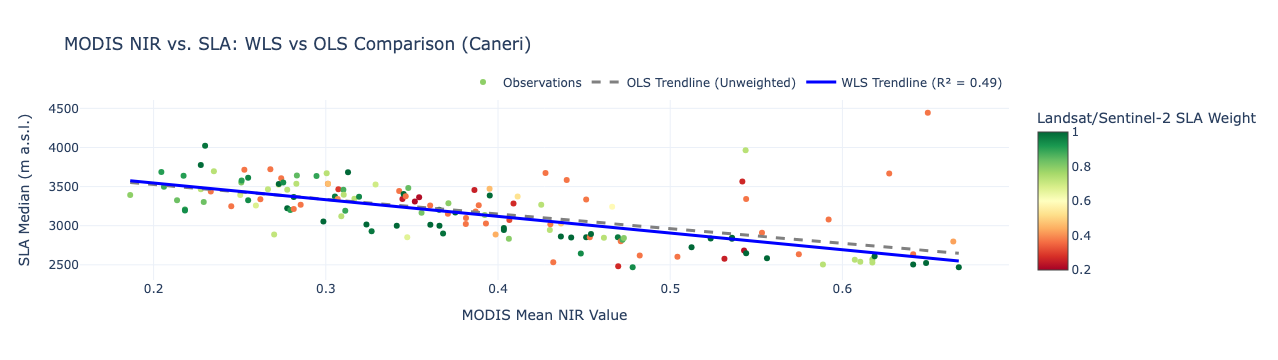

In [3]:
# Visualize the Regression for specific glacier
GLACIER_TO_PLOT = 'Caneri'

if GLACIER_TO_PLOT in clean_datasets:                      
    clean_df = clean_datasets[GLACIER_TO_PLOT].copy()

    # Sort by X-axis 
    clean_df = clean_df.sort_values(by='meanNIR')

    # Get the math from the master summary table
    stats = df_summary[df_summary['Glacier'] == GLACIER_TO_PLOT].iloc[0]
    
    wls_slope = stats['Slope Weighted']
    wls_intercept = stats['Intercept Weighted']
    ols_slope = stats['Slope Unweighted']
    ols_intercept = stats['Intercept Unweighted']
    
    # Calculate the Y values for the lines
    clean_df['trendline_weighted'] = clean_df['meanNIR'] * wls_slope + wls_intercept
    clean_df['trendline_unweighted'] = clean_df['meanNIR'] * ols_slope + ols_intercept

    # Build Figure
    fig_reg = go.Figure()

    # Add the scatter points, colored by the Landsat SLA Weight
    fig_reg.add_trace(go.Scatter(
        x=clean_df['meanNIR'], 
        y=clean_df['SLA_MP-median'],
        mode='markers',
        marker=dict(
            color=clean_df['LS_weight_final'], 
            colorscale='RdYlGn', 
            cmin=0.2, 
            cmax=1.0,  
            showscale=True,
            colorbar=dict(title="Landsat/Sentinel-2 SLA Weight")
        ),
        name='Observations',
        text=clean_df['date'], 
        hovertemplate="Date: %{text}<br>NIR: %{x:.4f}<br>SLA: %{y:.0f}m<br>Weight: %{marker.color:.2f}<extra></extra>"
    ))

    # Add the unweighted trendline 
    fig_reg.add_trace(go.Scatter(
        x=clean_df['meanNIR'],
        y=clean_df['trendline_unweighted'],
        mode='lines',
        line=dict(color='gray', width=3, dash='dash'),
        name='OLS Trendline (Unweighted)'
    ))

    # Add the weighted trendline 
    fig_reg.add_trace(go.Scatter(
        x=clean_df['meanNIR'],
        y=clean_df['trendline_weighted'],
        mode='lines',
        line=dict(color='blue', width=3),
        name=f'WLS Trendline (R² = {stats["R² Weighted"]:.2f})'
    ))

    # Apply clean layout
    fig_reg.update_layout(
        title=f"MODIS NIR vs. SLA: WLS vs OLS Comparison ({GLACIER_TO_PLOT})",
        xaxis_title="MODIS Mean NIR Value",
        yaxis_title="SLA Median (m a.s.l.)",
        template="plotly_white",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )

    fig_reg.show()
else:
    print(f"Error: Could not find data files for {GLACIER_TO_PLOT}.")

## 3. Continuous SLA Proxy Generation
Using the glacier-specific equations established by the WLS regression, we extrapolate the daily SLA across the entire 25-year study period using the NIR values of the MODIS dataset. This provides a gap-filled SLA proxy timeline.
The newly created data gets stored under the filename: 'predicted_sla_glacierName_WLS'

In [4]:
# Generate SLA proxy for all glaciers
final_proxy_datasets = {}

# Define the directory
final_output_dir = "../data/MODIS_data/predicted_sla"
os.makedirs(final_output_dir, exist_ok=True) 

# Loop through the models 
for name, model_results in trained_models.items():
    
    # Load the MODIS dataset
    modis_path = f"{modis_output_dir}/MODIS_{name}_complete.csv"
    
    if not os.path.exists(modis_path):
        continue
        
    df_full = pd.read_csv(modis_path)
    
    # Extract the slope and intercept from the statsmodels WLS results
    intercept = model_results.params[0]
    slope = model_results.params[1]
    
    # Predict SLA based on the raw Modis NIR 
    # y = m*x + b
    df_full['predicted_SLA_raw_WLS'] = np.nan 
    mask_raw = df_full['meanNIR'].notna()
    
    df_full.loc[mask_raw, 'predicted_SLA_raw_WLS'] = (df_full.loc[mask_raw, 'meanNIR'] * slope + intercept).round(2)
    
    # Predict SLA based on the smoothed Modis NIR 
    df_full['predicted_SLA_smoothed_WLS'] = np.nan 
    mask_smooth = df_full['meanNIR_weighted_7day'].notna()
    
    df_full.loc[mask_smooth, 'predicted_SLA_smoothed_WLS'] = (df_full.loc[mask_smooth, 'meanNIR_weighted_7day'] * slope + intercept).round(2)
    
    # Save to the dictionary
    final_proxy_datasets[name] = df_full
    
    # Export to CSV
    final_output_path = f"{final_output_dir}/predicted_SLA_{name}_WLS.csv"
    df_full.to_csv(final_output_path, index=False)
    
# Check if everything got exported correctly
if 'Caneri' in final_proxy_datasets:
    
    # Select columns to show, if they exist
    cols_to_show = ['date', 'meanNIR', 'predicted_SLA_raw_WLS']
    if 'meanNIR_weighted_7day' in final_proxy_datasets['Caneri'].columns:
        cols_to_show.extend(['meanNIR_weighted_7day', 'predicted_SLA_smoothed_WLS'])
        
    display(final_proxy_datasets['Caneri'][cols_to_show].dropna().head())

,date,meanNIR,predicted_SLA_raw_WLS,meanNIR_weighted_7day,predicted_SLA_smoothed_WLS
0,2000-05-04,0.7725,2323.92,0.7725,2323.92
1,2000-05-20,0.6785,2524.49,0.6220,2645.05
2,2000-05-21,0.5948,2703.09,0.6220,2645.05
3,2000-05-22,0.5834,2727.41,0.6220,2645.05
4,2000-06-12,0.5560,2785.87,0.4977,2910.27


## 4. Create static plot with WLS and OLS trendline

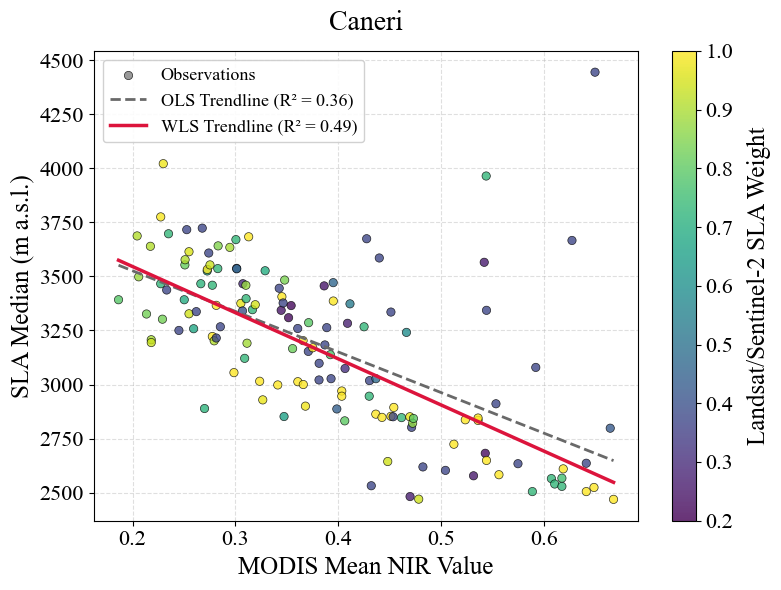

In [36]:
# Font type and size settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "serif"],
    "mathtext.fontset": "cm", 
    "xtick.labelsize": 16,    
    "ytick.labelsize": 16,    
    "axes.labelsize": 18,     
    "axes.titlesize": 20,     
    "legend.fontsize": 13,    
    "figure.titlesize": 20    
})

GLACIER_TO_PLOT = 'Caneri'

if GLACIER_TO_PLOT in clean_datasets:                      
    clean_df = clean_datasets[GLACIER_TO_PLOT].copy()

    # Sort by X-axis 
    clean_df = clean_df.sort_values(by='meanNIR')

    # Get the math from the master summary table
    stats = df_summary[df_summary['Glacier'] == GLACIER_TO_PLOT].iloc[0]
    
    # Extract both Weighted and Unweighted stats
    wls_slope = stats['Slope Weighted']
    wls_intercept = stats['Intercept Weighted']
    ols_slope = stats['Slope Unweighted']
    ols_intercept = stats['Intercept Unweighted']
    
    # Calculate the Y values for both lines
    clean_df['trendline_weighted'] = clean_df['meanNIR'] * wls_slope + wls_intercept
    clean_df['trendline_unweighted'] = clean_df['meanNIR'] * ols_slope + ols_intercept

    # Build figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Main scatter
    scatter = ax.scatter(
        clean_df['meanNIR'], 
        clean_df['SLA_MP-median'],
        c=clean_df['LS_weight_final'], 
        cmap='viridis', 
        vmin=0.2, 
        vmax=1.0,  
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        zorder=2
    )
    
    #Proxy for the legend
    ax.scatter(
        [], [], 
        c='gray', 
        alpha=0.8, 
        edgecolor='black', 
        linewidth=0.5, 
        label='Observations'
    )

    # Add the OLS trendline
    ax.plot(
        clean_df['meanNIR'], 
        clean_df['trendline_unweighted'],
        color='dimgray', 
        linewidth=2, 
        linestyle='--',
        zorder=3,
        label=f'OLS Trendline (R² = {stats["R² Unweighted"]:.2f})'
    )

    # Add the WLS trendline 
    ax.plot(
        clean_df['meanNIR'], 
        clean_df['trendline_weighted'],
        color='crimson', 
        linewidth=2.5, 
        zorder=4,
        label=f'WLS Trendline (R² = {stats["R² Weighted"]:.2f})'
    )

    # Add Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Landsat/Sentinel-2 SLA Weight", labelpad=10)

    # Apply layout
    ax.set_xlabel("MODIS Mean NIR Value")
    ax.set_ylabel("SLA Median (m a.s.l.)")
    ax.set_title(f"{GLACIER_TO_PLOT}", pad=15)
    
    ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
    
    ax.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.show()
    
    # Export the image
    output_path = f"/Users/sophierutimann/Documents/ESS_Bachelor/Semester6_FS26/Bachelorarbeit/Results/Weighted_regression/weighted_regression_{GLACIER_TO_PLOT}.png"
    fig.savefig(output_path, dpi=300, bbox_inches='tight')

else:
    print(f"Error: Could not find data files for {GLACIER_TO_PLOT}.")

## 5. Create subplots to add in the appendix
Here create static plots of the regression for all of the seven glaciers to add in the thesis in the appendix. 

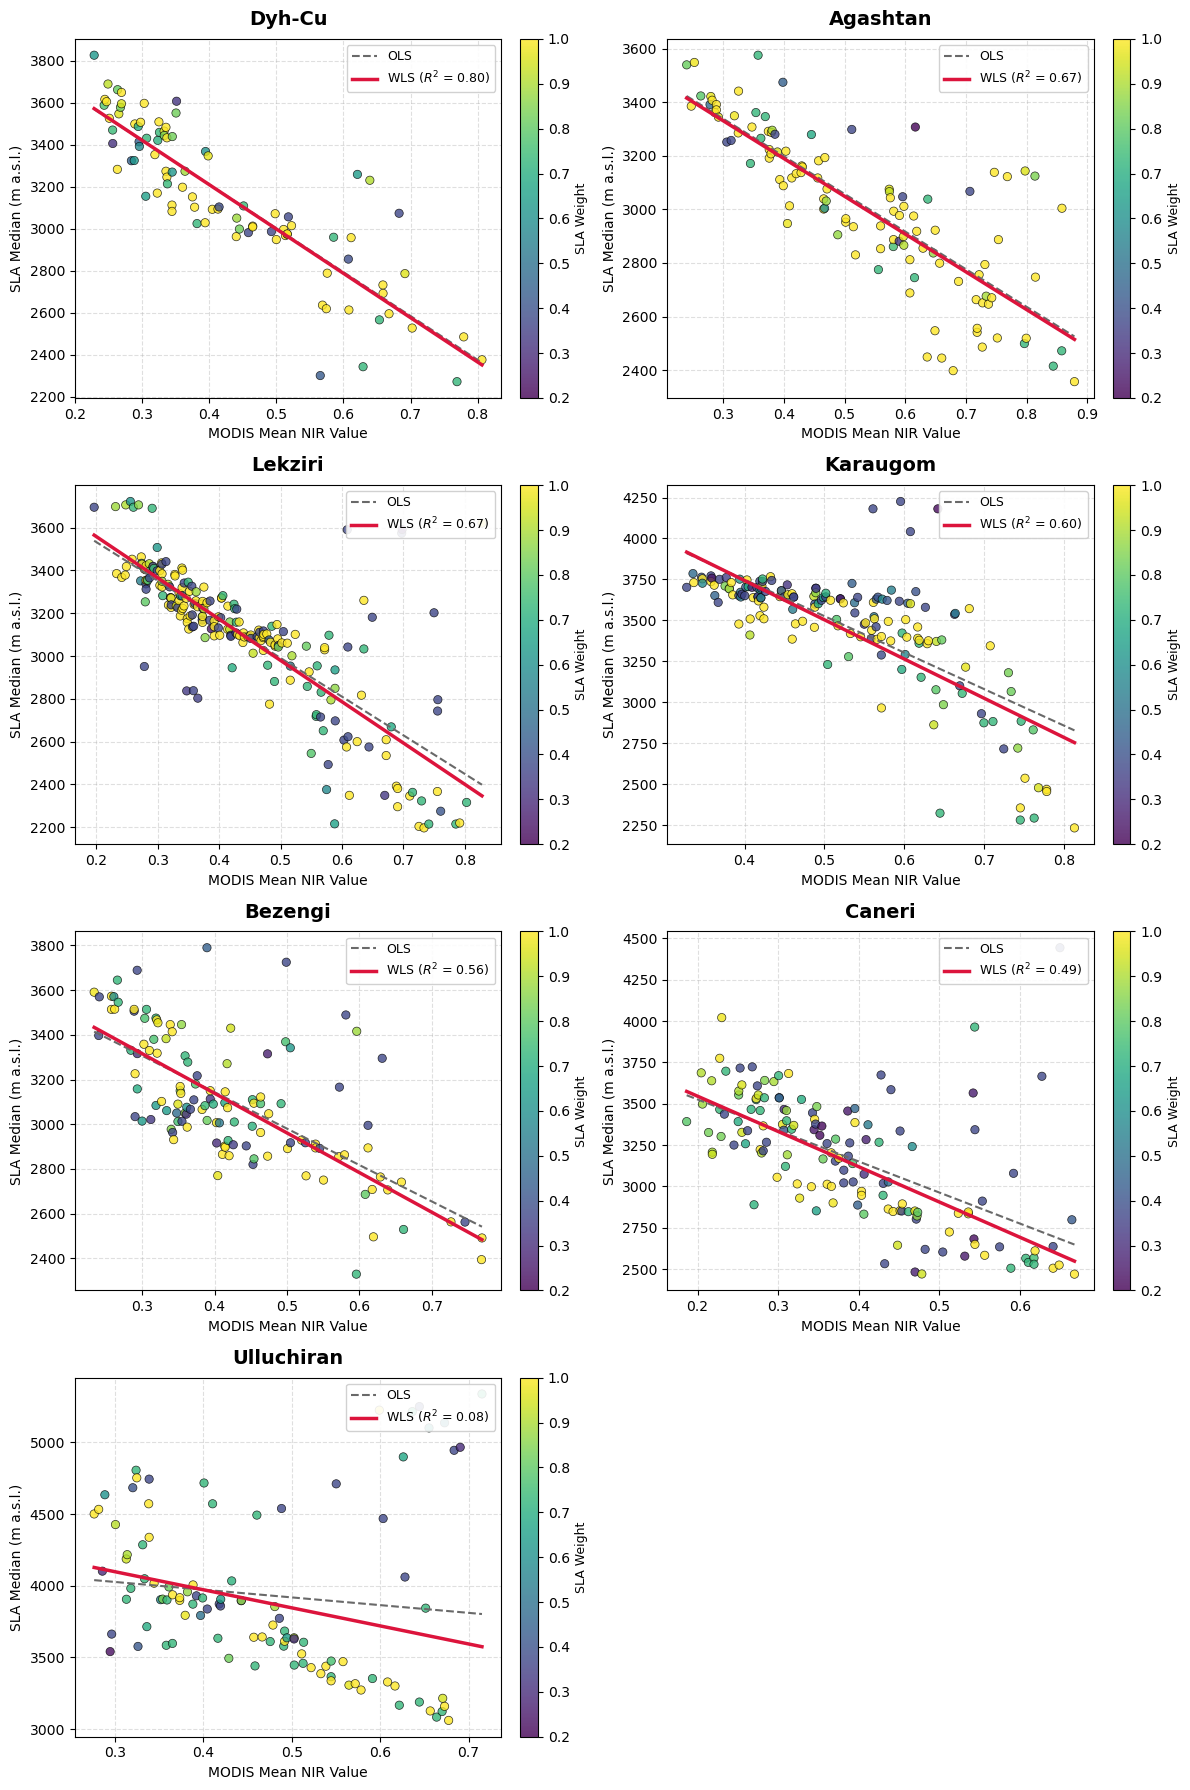

In [21]:
# Define the glaciers
study_glaciers_ordered = ['Dyh-Cu', 'Agashtan', 'Lekziri', 'Karaugom', 'Bezengi', 'Caneri', 'Ulluchiran']

# Build a 4x2 subplot grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 18))

# Flatten the 2D axes array into a 1D list to loop
axes = axes.flatten()

for i, glacier in enumerate(study_glaciers_ordered):
    ax = axes[i] 
    
    if glacier in clean_datasets:                      
        clean_df = clean_datasets[glacier].copy()

        # Sort by X-axis 
        clean_df = clean_df.sort_values(by='meanNIR')

        # Get the math from the master summary table
        stats = df_summary[df_summary['Glacier'] == glacier].iloc[0]
        
        wls_slope = stats['Slope Weighted']
        wls_intercept = stats['Intercept Weighted']
        ols_slope = stats['Slope Unweighted']
        ols_intercept = stats['Intercept Unweighted']
        
        # Calculate the Y values
        clean_df['trendline_weighted'] = clean_df['meanNIR'] * wls_slope + wls_intercept
        clean_df['trendline_unweighted'] = clean_df['meanNIR'] * ols_slope + ols_intercept

        # Add the scatter points
        scatter = ax.scatter(
            clean_df['meanNIR'], 
            clean_df['SLA_MP-median'],
            c=clean_df['LS_weight_final'], 
            cmap='viridis', 
            vmin=0.2, 
            vmax=1.0,  
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5,
            zorder=2
        )

        # Add the OLS trendline
        ax.plot(
            clean_df['meanNIR'], 
            clean_df['trendline_unweighted'],
            color='dimgray', 
            linewidth=1.5, 
            linestyle='--',
            zorder=3,
            label=f'OLS ($R^2$ = {stats['R² Unweighted']:.2f})'
        )

        # Add the WLS trendline 
        ax.plot(
            clean_df['meanNIR'], 
            clean_df['trendline_weighted'],
            color='crimson', 
            linewidth=2.5, 
            zorder=4,
            label=f'WLS ($R^2$ = {stats['R² Weighted']:.2f})'
        )

        # Apply layout for this specific subplot
        ax.set_title(f"{glacier}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel("MODIS Mean NIR Value", fontsize=10)
        ax.set_ylabel("SLA Median (m a.s.l.)", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=1)
        ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
        
        # Add individual colorbars 
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("SLA Weight", fontsize=9)
        
    else:
        ax.text(0.5, 0.5, f'No data for {glacier}', ha='center', va='center')

# Hide the 8. subplot, since only 7 glaciers 
axes[7].axis('off')


plt.tight_layout()

plt.show()

# Export the image
# output_path = f"../results/Weighted_regression/Appendix_All_Regressions.png"
# fig.savefig(output_path, dpi=300, bbox_inches='tight')